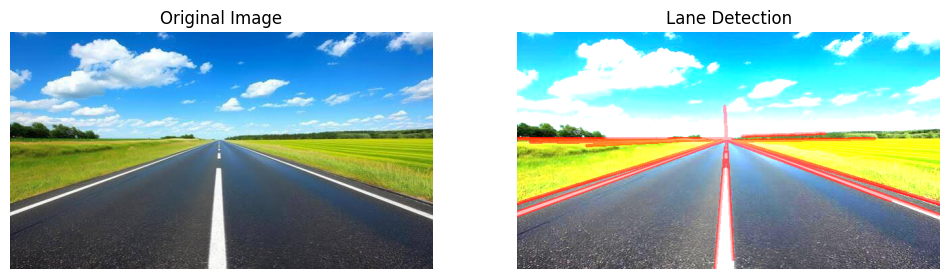

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("road.jpg")

# Convert to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Detect edges
edges = cv2.Canny(blur, 50, 150)

# Detect lane lines using Hough Transform
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=100,
    minLineLength=50,
    maxLineGap=50
)

# Draw detected lines
lane_image = image_rgb.copy()

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(
            lane_image,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            3
        )

# Blend original image and lane image
output = cv2.addWeighted(
    image_rgb,
    0.8,
    lane_image,
    1,
    0
)

# Display Original and Output
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(output)
plt.title("Lane Detection")
plt.axis("off")

plt.show()